In [46]:
import pandas as pd
df=pd.read_csv("hand/english.csv")

In [47]:
df.head(5)

,image,label
0,Img/img001-001.png,0
1,Img/img001-002.png,0
2,Img/img001-003.png,0
3,Img/img001-004.png,0
4,Img/img001-005.png,0


In [48]:
df.tail(5)

,image,label
3405,Img/img062-051.png,z
3406,Img/img062-052.png,z
3407,Img/img062-053.png,z
3408,Img/img062-054.png,z
3409,Img/img062-055.png,z


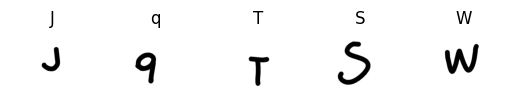

In [49]:
import cv2
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
path="hand/"
values=random.sample(range(len(df)),5)
for i,idx in enumerate(values):
    img=os.path.join(path,df.iloc[idx]["image"])
    label=df.iloc[idx]["label"]

    image=cv2.imread(img,cv2.IMREAD_GRAYSCALE)
    plt.subplot(1,5,i+1)
    plt.imshow(image,cmap="gray")
    plt.title(label)
    plt.axis("off")


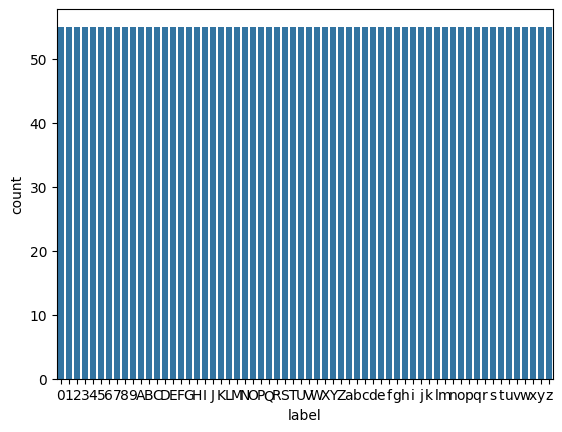

In [50]:
sns.countplot(x="label",data=df)
plt.show()

In [51]:
values=random.sample(range(len(df)),5)
im=[]
for i,idx in enumerate(values):
    img=os.path.join(path,df.iloc[idx]["image"])
    label=df.iloc[idx]["label"]
    image=cv2.imread(img,cv2.IMREAD_GRAYSCALE)
    im.append(image.shape)

print(set(im))

{(900, 1200)}


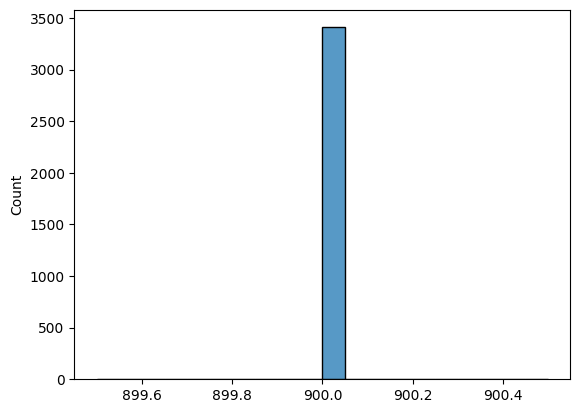

In [52]:
height=[]
weight=[]
for i in range(len(df)):
    img=os.path.join(path,df.iloc[i]["image"])
    image=cv2.imread(img,cv2.IMREAD_GRAYSCALE)
    h,w=image.shape
    height.append(h)
    weight.append(w)
sns.histplot(height,bins=20)
plt.show()

In [53]:
x=[]
y=[]
for i in range(len(df)):
    img=os.path.join(path,df.iloc[i]["image"])
    label=df.iloc[i]["label"]
    image=cv2.imread(img,cv2.IMREAD_GRAYSCALE)
    image=cv2.resize(image,(28,28))
    image=image/255.0
    image=image.flatten()
    x.append(image)
    y.append(label)

x=np.array(x)
y=np.array(y)
print(x.shape)
print(y.shape)

(3410, 784)
(3410,)


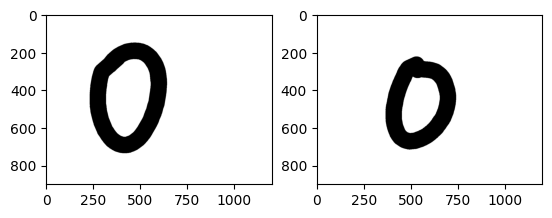

In [54]:
for i in range(2):
    img=os.path.join(path,df.iloc[i]["image"])
    image=cv2.imread(img,cv2.IMREAD_GRAYSCALE)
    plt.subplot(1,2,i+1)
    plt.imshow(image,cmap="gray")

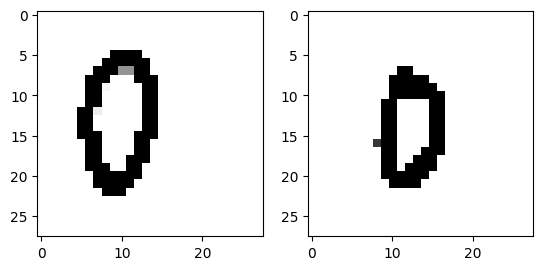

In [55]:
for i in range(2):
    img=os.path.join(path,df.iloc[i]["image"])
    image=cv2.imread(img,cv2.IMREAD_GRAYSCALE)
    image=cv2.resize(image,(28,28))
    plt.subplot(1,2,i+1)
    plt.imshow(image,cmap="gray")

In [56]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)
print(x_train.shape)
print(x_test.shape)

(2728, 784)
(682, 784)


In [57]:
def step_function(i):
    return np.where(i>0,1,0)
class pla:
    def __init__(self,lr,epochs):
        self.lr=lr
        self.epochs=epochs

    def fit(self,x,y):
        self.weights=np.zeros(x.shape[1])
        self.bias=0
        self.error=[]

        for _ in range(self.epochs):
            errors=0
            for xi,yi in zip(x,y):
                i=np.dot(self.weights,xi)+self.bias
                y_hat=step_function(i)
    
                update=self.lr*(yi-y_hat)
                self.weights+=update*xi
                self.bias+=update
    
                errors+=abs(update)
    
            self.error.append(errors)

    def scores(self,x):
        return np.dot(x,self.weights)+self.bias

    
            

In [58]:
classes=np.unique(y_train)
pla_models=[]
for cls in classes:
    y_bin=np.where(y_train==cls,1,0)
    model=pla(lr=0.01,epochs=50)
    model.fit(x_train,y_bin)
    pla_models.append(model)

def pla_predict(x_test,pla_models,classes):
    scores=[]
    for i in pla_models:
        scores.append(i.scores(x_test))
    scores=np.array(scores)
    best=np.argmax(scores,axis=0)
    return classes[best]

scores_roc=[]
for i in pla_models:
    scores_roc.append(i.scores(x_test))
scores_roc=np.array(scores_roc).T
y_pred=pla_predict(x_test,pla_models,classes)

In [59]:
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score,confusion_matrix
print("PLA Accuracy: ",accuracy_score(y_test,y_pred))
print("PLA Precision: ",precision_score(y_test,y_pred,average='macro'))
print("PLA Recall: ",recall_score(y_test,y_pred,average='macro'))
print("PLA F1-score: ",f1_score(y_test,y_pred,average='macro'))

PLA Accuracy:  0.1656891495601173
PLA Precision:  0.2681845331155801
PLA Recall:  0.16568914956011732
PLA F1-score:  0.14901775655549174


/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


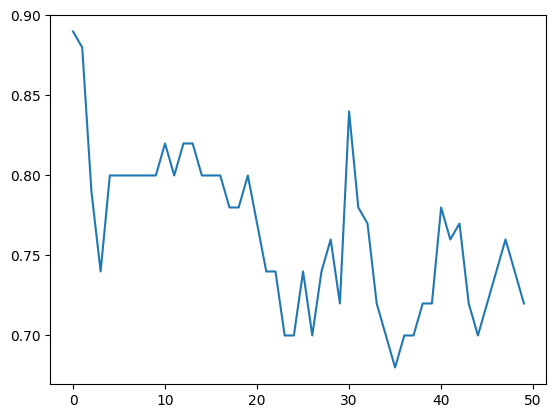

In [60]:
plt.plot(model.error)
plt.show()

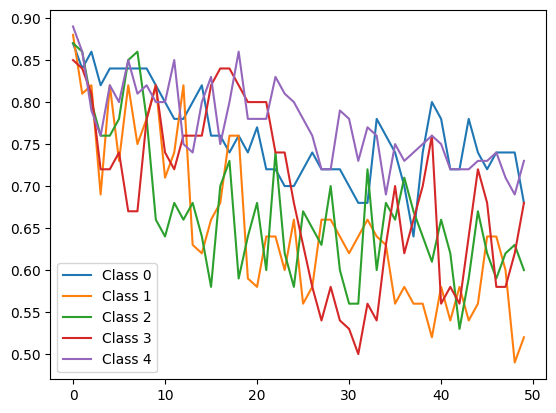

In [167]:
for i,model in enumerate(pla_models[:5]):
    plt.plot(model.error, label=f"Class {classes[i]}")
plt.legend()
plt.show()

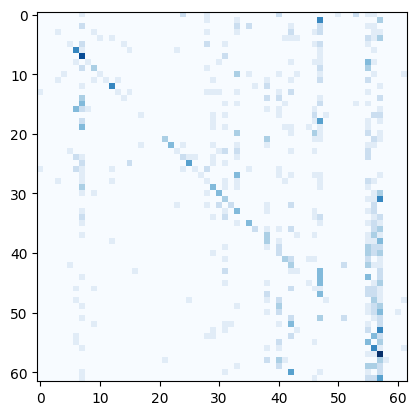

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [61]:
cm=confusion_matrix(y_test,y_pred,labels=classes)
plt.imshow(cm,cmap="Blues")
plt.show()
print(cm)

In [169]:
print(y_pred[:10])

['7' 'X' 'u' 'V' 'e' 'O' 'u' 'g' 'v' 'l']


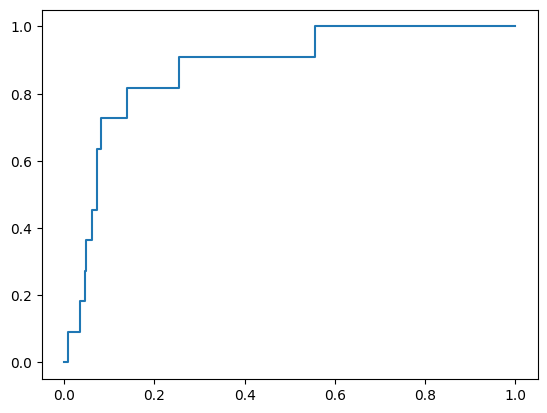

In [67]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve

y_test_bin=label_binarize(y_test,classes=classes)
for i in range(5):
    fpr,tpr,_=roc_curve(y_test_bin[:,i],scores_roc[:,i])

plt.plot(fpr,tpr)
plt.show()

In [171]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [172]:
from sklearn.neural_network import MLPClassifier
model=MLPClassifier(hidden_layer_sizes=(64,32),activation='relu',solver='adam',learning_rate_init=0.001,batch_size=32,max_iter=200,random_state=42)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [173]:
print(accuracy_score(y_test,y_pred))

0.3255131964809384


In [45]:
from sklearn.model_selection import GridSearchCV
mlp=MLPClassifier(max_iter=200)
param_grid={"learning_rate_init":[0.001,0.01,0.1],"hidden_layer_sizes":[(64,32),(32,)],"activation":["relu","logistic","tanh"],"solver":["adam","sgd"],"batch_size":[32,64]}
grid=GridSearchCV(estimator=mlp,param_grid=param_grid,cv=5,scoring="accuracy")
grid.fit(x_train,y_train)
print(grid.best_params_)
best_model=grid.best_estimator_
y_pred_grid=best_model.predict(x_test)

NameError: name 'MLPClassifier' is not defined

In [181]:
print(accuracy_score(y_test,y_pred_grid))

0.32991202346041054


/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


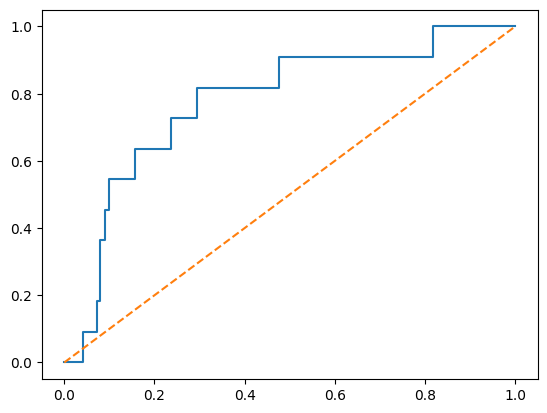

In [185]:
classes=best_model.classes_
y_test_bin=label_binarize(y_test,classes=classes)
y_score=best_model.predict_proba(x_test)
for i in range(len(classes)):
    fpr,tpr,_=roc_curve(y_test_bin[:,i],y_score[:,i])
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],"--")
plt.show()

In [26]:
def step_fuc(i):
    return np.where(i>0,1,0)
class Perceptron:
    def __init__(self,lr,epochs):
        self.lr=lr
        self.epochs=epochs

    def fit(self,x,y):
        self.weights=np.zeros(x.shape[1])
        self.bias=0
        self.error=[]
        for _ in range(self.epochs):
            errors=0
            for xi,yi in zip(x,y):
                linear=np.dot(xi,self.weights)+self.bias
                y_hat=step_fuc(linear)
                updates=self.lr*(yi-y_hat)
                self.weights+=updates*xi
                self.bias+=updates
                errors+=updates
            self.error.append(errors)

    def score(self,x):
        return np.dot(x,self.weights)+self.bias

In [41]:
classes=np.unique(y_train)
pla_models=[]
for cls in classes:
    y_bin=np.where(y_train==cls,1,0)
    pla=Perceptron(lr=0.01,epochs=50)
    pla.fit(x_train,y_bin)
    pla_models.append(pla)


def predict(x_test,pla_models,classes):
    scores=[]
    for pla in pla_models:
        score=pla.score(x_test)
        scores.append(score)
    index=np.argmax(scores,axis=0)
    return classes[index]
y_pred_pla=predict(x_test,pla_models,classes)




In [42]:
y_score=[]
for pla in pla_models:
    score=pla.score(x_test)
    y_score.append(score)
y_score=np.array(y_score).T

In [44]:
from sklearn.metrics import accuracy_score,roc_curve,auc
print(accuracy_score(y_test,y_pred_pla))

ValueError: Classification metrics can't handle a mix of multilabel-indicator and multiclass targets

In [39]:
from sklearn.preprocessing import label_binarize
y_test=label_binarize(y_test,classes=classes)
fpr,tpr,_=roc_cuve(y_test[:,1],y_score)
plt.show(fpt,tpr)

NameError: name 'roc_cuve' is not defined